## 1. Import e caricamento dati

Carichiamo le 5 tabelle core (`races`, `results`, `drivers`, `constructors`, `qualifying`). 
Le altre tabelle disponibili (`lap_times`, `pit_stops`, ecc.) le aggiungeremo solo se emergerà la necessità durante il feature engineering.

In [5]:
import pandas as pd                 # Manipolazione dati tabellari
import numpy as np                  # Manipolazione array multidimensionali
import matplotlib.pyplot as plt     # Visualizzazione dati
import seaborn as sns               # Visualizzazione dati avanzata

In [6]:
sns.set_theme(style="whitegrid")    

In [7]:
# na_values dice esplicitamente a pandas di trattare anche la stringa "\N" come valore mancante (NaN), oltre ai default che già riconosce
na_vals = ["\\N"]

races = pd.read_csv("../data/raw/races.csv", na_values=na_vals)
results = pd.read_csv("../data/raw/results.csv", na_values=na_vals)
drivers = pd.read_csv("../data/raw/drivers.csv", na_values=na_vals)
constructors = pd.read_csv("../data/raw/constructors.csv", na_values=na_vals)
qualifying = pd.read_csv("../data/raw/qualifying.csv", na_values=na_vals)

In [8]:
# Primo controllo di sanità: righe e colonne di ciascuna tabella
print("Races:", races.shape)
print("Results:", results.shape)
print("Drivers:", drivers.shape)
print("Constructors:", constructors.shape)
print("Qualifying:", qualifying.shape)

Races: (1125, 18)
Results: (26759, 18)
Drivers: (861, 9)
Constructors: (212, 5)
Qualifying: (10494, 9)


## 2. Prima ispezione della tabella principale

`results` è la tabella più importante: contiene un record per ogni pilota in ogni gara, con il risultato finale. 
Le colonne chiave sono `positionOrder` (piazzamento finale) e `grid` (posizione di partenza).

In [9]:
results.head()  # Visualizziamo le prime 5 righe della tabella dei risultati per avere un'idea della struttura dei dati.

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [10]:
results.describe()  # Statistiche descrittive per le colonne numeriche della tabella dei risultati.

,resultId,raceId,driverId,constructorId,number,grid,position,positionOrder,points,laps,milliseconds,fastestLap,rank,fastestLapSpeed,statusId
count,26759.000000,26759.000000,26759.000000,26759.000000,26753.000000,26759.000000,15806.000000,26759.000000,26759.000000,26759.000000,7.680000e+03,8252.000000,8510.000000,8252.000000,26759.000000
mean,13380.977391,551.687283,278.673530,50.180537,18.153927,11.134796,8.020499,12.794051,1.987632,46.301768,6.185833e+06,42.732913,10.334313,204.116330,17.224971
std,7726.134642,313.265036,282.703039,61.551498,15.581135,7.202860,4.840796,7.665951,4.351209,29.496557,1.669306e+06,16.603460,6.140957,21.377265,26.026104
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,5.260000e+02,1.000000,0.000000,89.540000,1.000000
25%,6690.500000,300.000000,57.000000,6.000000,7.000000,5.000000,4.000000,6.000000,0.000000,23.000000,5.378454e+06,33.000000,5.000000,193.322500,1.000000
50%,13380.000000,531.000000,172.000000,25.000000,16.000000,11.000000,8.000000,12.000000,0.000000,53.000000,5.788194e+06,46.000000,10.000000,204.894000,10.000000
75%,20069.500000,811.000000,399.500000,63.000000,24.000000,17.000000,11.000000,18.000000,2.000000,66.000000,6.402676e+06,54.000000,15.000000,217.324000,14.000000
max,26764.000000,1144.000000,862.000000,215.000000,208.000000,34.000000,33.000000,39.000000,50.000000,200.000000,1.509054e+07,85.000000,24.000000,257.320000,141.000000


I CSV originali (fonte Ergast) usano il carattere `\N` per indicare  "dato non disponibile", invece dello standard NaN. 
Verifichiamo se pandas l'ha già riconosciuto automaticamente o se dobbiamo intervenire.

In [11]:
results.info()

# .isnull().sum() conta i valori NaN espliciti per colonna (se il conteggio è 0 ovunque ma sappiamo che ci sono \N nei dati grezzi, significa che 
# pandas NON li ha riconosciuti come mancanti, e dobbiamo ricaricare specificando na_values=["\\N"])
results.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26753 non-null  float64
 5   grid             26759 non-null  int64  
 6   position         15806 non-null  float64
 7   positionText     26759 non-null  str    
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             7680 non-null   str    
 12  milliseconds     7680 non-null   float64
 13  fastestLap       8252 non-null   float64
 14  rank             8510 non-null   float64
 15  fastestLapTime   8252 non-null   str    
 16  fastestLapSpeed  8252 non-null   float64
 17  statusId         26759 

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64

## 4. Filtro all'era moderna

I regolamenti, il punteggio e persino il formato del weekend sono cambiati profondamente dal 1950 a oggi. 
Includere l'era pre-2000 nel training potrebbe introdurre rumore invece che segnale utile.

In [12]:
races_recent = races[races["year"] >= 2000]  # Filtriamo le gare a partire dal 2000
print(f"Gare dal 2000 in poi: {races_recent.shape[0]} su {races.shape[0]} totali") # shape[0] restituisce il numero di righe

Gare dal 2000 in poi: 479 su 1125 totali


In [13]:
# Quante gare per anno, dal 2000 in poi — ci aiuta a vedere se c'è un salto naturale di qualità/quantità dati intorno al 2004
races[races["year"] >= 2000]["year"].value_counts().sort_index()

year
2000    17
2001    17
2002    17
2003    16
2004    18
2005    19
2006    18
2007    17
2008    18
2009    17
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
Name: count, dtype: int64

## 5. Il giro veloce è davvero predittivo del podio?

Prima di decidere se sacrificare gli anni 2000-2003 per avere queste feature, verifichiamo quanto sono effettivamente legate al risultato 
finale, usando solo i dati dal 2004 in poi (dove esistono).

In [14]:
# Uniamo 'results' con 'races' per avere l'anno di ogni gara ('results' ha solo 'raceId', ma non l'anno)
results_with_year = results.merge(
    races[["raceId", "year"]],
    on="raceId",
    how="left"
)

# Filtriamo solo dal 2004 in poi, dove esiste il giro veloce
results_2004plus = results_with_year[results_with_year["year"] >= 2004].copy()  # Facciamo una copia per evitare il SettingWithCopyWarning

# Creiamo il target: podio = posizione finale tra 1 e 3
results_2004plus["podium"] = results_2004plus["positionOrder"] <= 3

print(f"Righe disponibili dal 2004 in poi: {results_2004plus.shape[0]} su {results_with_year.shape[0]} totali")
print(f"Numero podi: {results_2004plus['podium'].sum()} su {results_2004plus.shape[0]} totali")

Righe disponibili dal 2004 in poi: 8650 su 26759 totali
Numero podi: 1236 su 8650 totali


In [16]:
# Confrontiamo il "rank" del giro veloce (1 = giro più veloce) tra chi ha fatto podio e chi no
# Nota: rank ha NaN per chi non ha completato abbastanza giri per essere classificato, quindi va gestito separatamente

print("Rank giro veloce - media per gruppo: ")
print(results_2004plus.groupby("podium")["rank"].mean())

print("\nQuanti podi hanno un rank del giro veloce mancante (NaN)?")
print(results_2004plus[results_2004plus["podium"]]["rank"].isnull().sum(),
      "su", results_2004plus["podium"].sum())

Rank giro veloce - media per gruppo: 
podium
False    11.470855
True      3.645631
Name: rank, dtype: float64

Quanti podi hanno un rank del giro veloce mancante (NaN)?
0 su 1236


## 6. Decisione finale sul range di anni

L'ipotesi iniziale (dal 2000) è stata rivista dopo aver verificato il potere predittivo del giro veloce: 
chi fa podio ha un rank medio di 3.6 contro l'11.5 di chi non lo fa — una differenza troppo forte per scartarla. 
Poiché queste colonne esistono solo dal 2004, restringiamo il range, accettando di perdere il 14% delle gare filtrate (67 su 479) in cambio di un dataset completo su tutte le colonne.

In [17]:
# Decisione finale: 2004-2024
races_recent = races[races["year"] >= 2004]
print(f"Gare dal 2004 in poi: {races_recent.shape[0]} su {races.shape[0]} totali") # shape[0] restituisce il numero di righe

Gare dal 2004 in poi: 412 su 1125 totali


## 7. Visualizzati: target e relazione griglia-risultato

Due grafici per visualizzare quanto è sbilanciato il target (podio vs non podio) e quanto la posizione di partenza influenza da sola il risultato finale

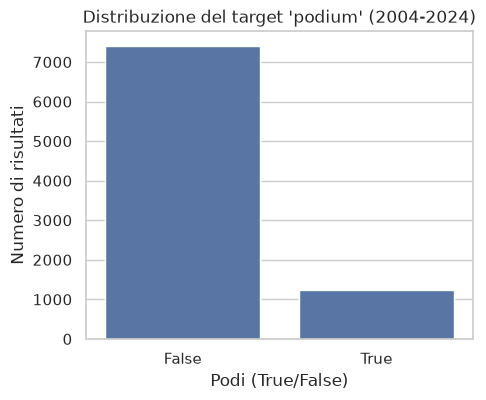

In [18]:
# Ricreiamo il dataset filtrato per il 2004 in poi con il target 'podium'
results_final = results_with_year[results_with_year["year"] >= 2004].copy()  # Facciamo una copia per evitare il SettingWithCopyWarning
results_final["podium"] = results_final["positionOrder"] <= 3

# 'countplot' di Seaborn conta automaticamente quante righe per ciascun valore della colonna 'podium' e le visualizza come barre verticali
plt.figure(figsize=(5, 4)) # Impostiamo la dimensione della figura
sns.countplot(x="podium", data=results_final) # Creiamo il grafico a barre per la colonna 'podium'
plt.title("Distribuzione del target 'podium' (2004-2024)") # Aggiungiamo un titolo al grafico
plt.xlabel("Podi (True/False)") # Etichetta asse x
plt.ylabel("Numero di risultati") # Etichetta asse y
plt.show() # Mostriamo il grafico

In [19]:
# Percentuale esatta per quantificare lo sbilanciamento
percentage_podium = results_final["podium"].mean() * 100 
print(f"Percentuale di risultati in podio: {percentage_podium:.2f}%")

Percentuale di risultati in podio: 14.29%


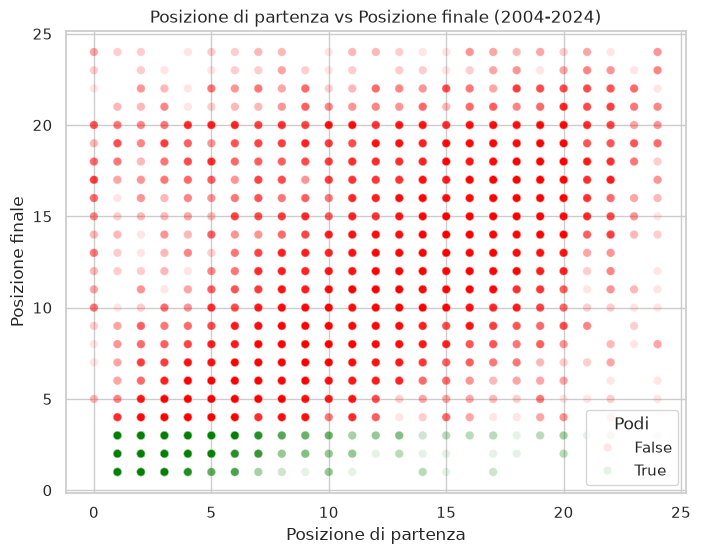

In [23]:
# Scatterplot per gestire la soprapposizione dei punti e rendere più leggibile il grafico
plt.figure(figsize=(8, 6)) # Impostiamo la dimensione della figura
sns.scatterplot(
    data=results_final, # Dati da visualizzare
    x="grid", # Valore sull'asse x (posizione di partenza)
    y="positionOrder", # Valore sull'asse y (posizione finale)
    hue="podium", # Colore dei punti in base al target 'podium'
    alpha=0.1,  # Trasparenza dei punti per ridurre la sovrapposizione
    palette={True: "green", False: "red"}  # Definiamo i colori per ciascun valore di 'podium'
)

plt.title("Posizione di partenza vs Posizione finale (2004-2024)") # Aggiungiamo un titolo al grafico
plt.xlabel("Posizione di partenza") # Etichetta asse x
plt.ylabel("Posizione finale") # Etichetta asse y
plt.legend(title="Podi") # Aggiungiamo una legenda con titolo
plt.show() # Mostriamo il grafico

In [25]:
# Correlazione numerica tra le due variabili
corr = results_final["grid"].corr(results_final["positionOrder"])
print(f"Correlazione tra posizione di partenza e posizione finale: {corr:.3f}")

Correlazione tra posizione di partenza e posizione finale: 0.579
